Regresja logistyczna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Customer-Churn-Records.csv')

# --- Podstawowe info ---
print(df.shape)           # ile wierszy i kolumn
print(df.dtypes)          # typy danych
print(df.isnull().sum())  # brakujące wartości
print(df.describe())      # statystyki opisowe

# --- Proporcja klas (KLUCZOWE) ---
print(df['Exited'].value_counts(normalize=True))

(10000, 18)
RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dt

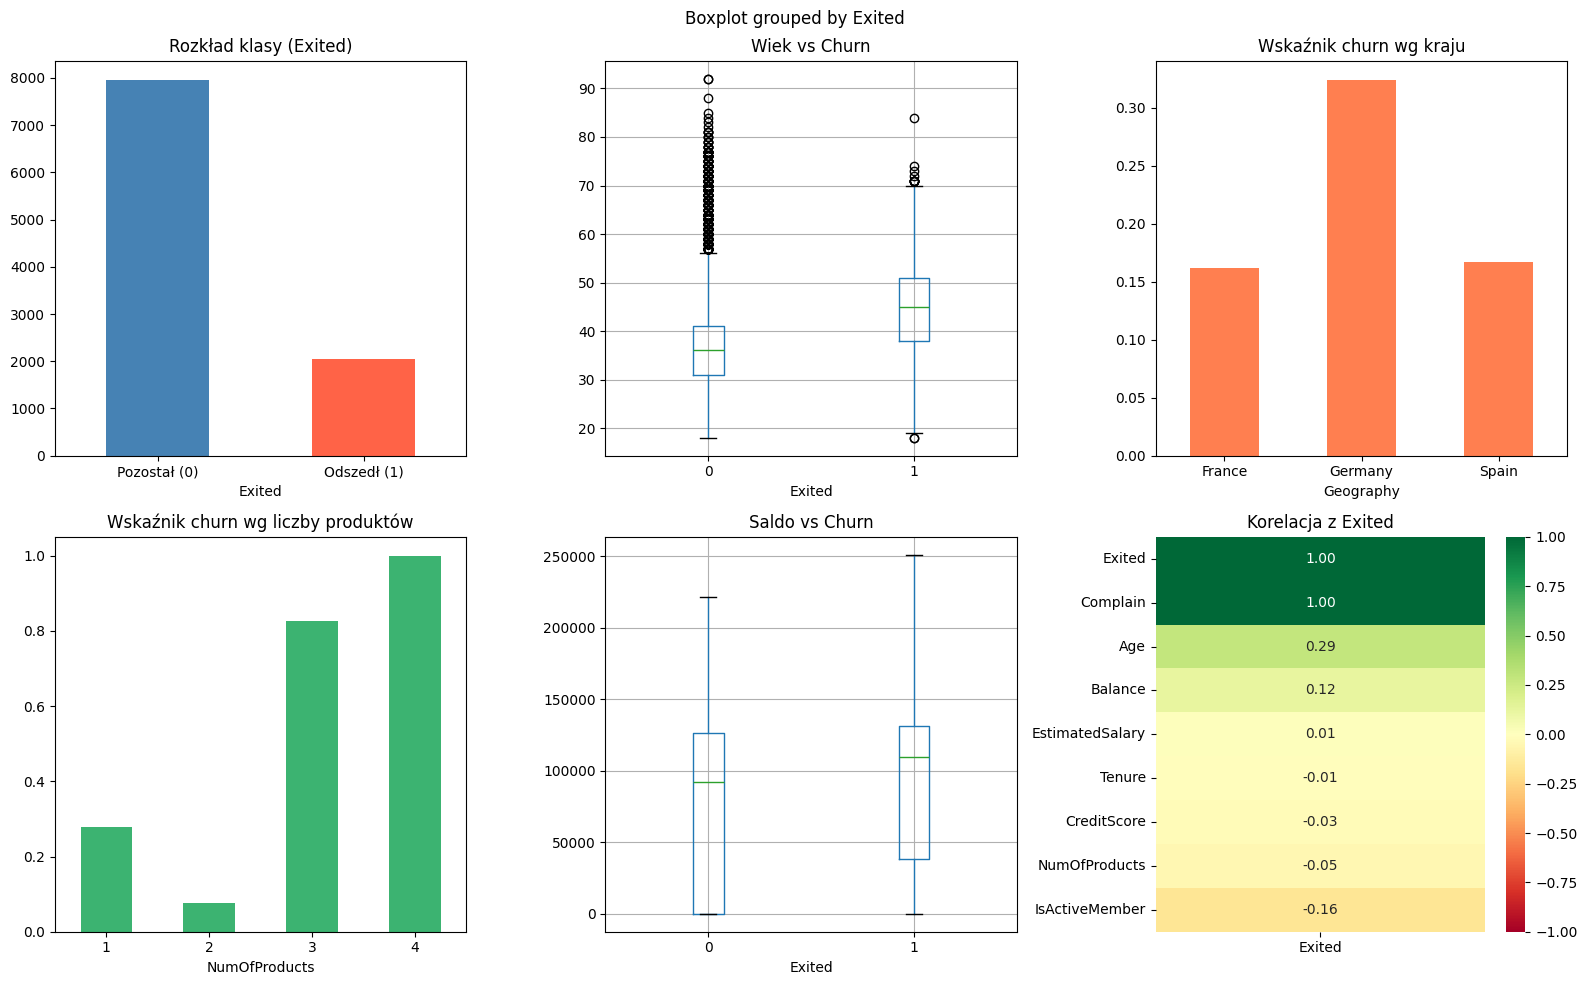

Zapisano eda_plots.png

Korelacja Complain ↔ Exited: 0.9957
Crosstab Complain vs Exited:
Exited           0         1
Complain                    
0         0.999497  0.000503
1         0.004892  0.995108


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - Bank Customer Churn', fontsize=16)

# 1. Rozkład targetu
df['Exited'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Rozkład klasy (Exited)')
axes[0,0].set_xticklabels(['Pozostał (0)', 'Odszedł (1)'], rotation=0)

# 2. Churn wg wieku
df.boxplot(column='Age', by='Exited', ax=axes[0,1])
axes[0,1].set_title('Wiek vs Churn')
axes[0,1].set_xlabel('Exited')

# 3. Churn wg Geography
churn_geo = df.groupby('Geography')['Exited'].mean()
churn_geo.plot(kind='bar', ax=axes[0,2], color='coral')
axes[0,2].set_title('Wskaźnik churn wg kraju')
axes[0,2].set_xticklabels(churn_geo.index, rotation=0)

# 4. Churn wg NumOfProducts
churn_prod = df.groupby('NumOfProducts')['Exited'].mean()
churn_prod.plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Wskaźnik churn wg liczby produktów')
axes[1,0].set_xticklabels(churn_prod.index, rotation=0)

# 5. Balance wg Exited
df.boxplot(column='Balance', by='Exited', ax=axes[1,1])
axes[1,1].set_title('Saldo vs Churn')
axes[1,1].set_xlabel('Exited')

# 6. Korelacja Complain vs Exited (WAŻNE!)
corr_matrix = df[['CreditScore','Age','Tenure','Balance','NumOfProducts',
                   'EstimatedSalary','IsActiveMember','Complain','Exited']].corr()
sns.heatmap(corr_matrix[['Exited']].sort_values('Exited', ascending=False),
            annot=True, fmt='.2f', ax=axes[1,2], cmap='RdYlGn', vmin=-1, vmax=1)
axes[1,2].set_title('Korelacja z Exited')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano eda_plots.png")

# Sprawdź dokładnie korelację Complain-Exited
print("\nKorelacja Complain ↔ Exited:", df['Complain'].corr(df['Exited']).round(4))
print("Crosstab Complain vs Exited:")
print(pd.crosstab(df['Complain'], df['Exited'], normalize='index'))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. Usuń kolumny bezużyteczne i leakage ---
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Complain'])

# --- 2. Traktuj NumOfProducts jako kategoryczną (nieliniowy wzorzec!) ---
df_clean['NumOfProducts'] = df_clean['NumOfProducts'].astype(str)

# --- 3. Zdefiniuj cechy i target ---
X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

# --- 4. Zidentyfikuj typy kolumn ---
categorical_cols = ['Geography', 'Gender', 'Card Type', 'NumOfProducts']
numerical_cols   = ['CreditScore', 'Age', 'Tenure', 'Balance',
                    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
                    'Satisfaction Score', 'Point Earned']

# --- 5. Stratyfikowany podział train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Churn w train: {y_train.mean():.3f}, w test: {y_test.mean():.3f}")

# --- 6. Transformator kolumn ---
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

print("\nPreprocessor gotowy!")
print(f"Kolumny numeryczne ({len(numerical_cols)}): {numerical_cols}")
print(f"Kolumny kategoryczne ({len(categorical_cols)}): {categorical_cols}")

Train: (8000, 13), Test: (2000, 13)
Churn w train: 0.204, w test: 0.204

Preprocessor gotowy!
Kolumny numeryczne (9): ['CreditScore', 'Age', 'Tenure', 'Balance', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Satisfaction Score', 'Point Earned']
Kolumny kategoryczne (4): ['Geography', 'Gender', 'Card Type', 'NumOfProducts']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

# --- Pipeline: preprocessor → selekcja cech → model ---
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=10)),   # selekcja 10 najlepszych cech
    ('clf', LogisticRegression(
        class_weight='balanced',   # kompensacja niezbalansowanych klas
        max_iter=1000,
        random_state=42
    ))
])

# --- Dopasuj model ---
pipeline.fit(X_train, y_train)

# --- Podstawowe wyniki na zbiorze testowym ---
y_pred      = pipeline.predict(X_test)
y_proba     = pipeline.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Zostaje', 'Odchodzi']))

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

print("\n=== Macierz pomyłek ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

# --- Walidacja krzyżowa (5-fold) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"\n=== Cross-Val AUC (5-fold) ===")
print(f"Fold scores: {cv_auc.round(4)}")
print(f"Mean: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

     Zostaje       0.93      0.77      0.84      1592
    Odchodzi       0.46      0.78      0.58       408

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000


AUC-ROC: 0.8491

=== Macierz pomyłek ===
[[1219  373]
 [  91  317]]
TN=1219, FP=373, FN=91, TP=317

=== Cross-Val AUC (5-fold) ===
Fold scores: [0.8291 0.8336 0.8388 0.8164 0.8297]
Mean: 0.8295 ± 0.0074


Bazowy zysk (brak modelu): -124,072 PLN

Optymalny próg:  0.68
Maksymalny zysk: -60,981
Zysk przy progu 0.5: -72,208


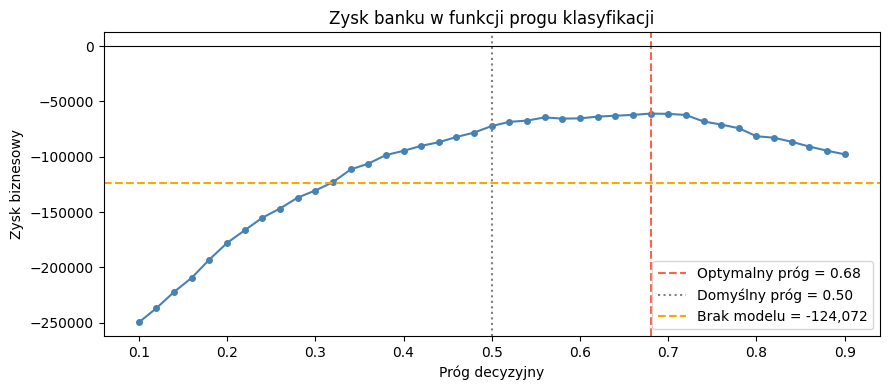


=== Macierz pomyłek przy progu 0.68 ===
[[1449  143]
 [ 177  231]]
TN=1449, FP=143, FN=177, TP=231
              precision    recall  f1-score   support

     Zostaje       0.89      0.91      0.90      1592
    Odchodzi       0.62      0.57      0.59       408

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [ ]:
# --- Metryka biznesowa z treści zadania ---
def business_profit(y_true, y_proba, threshold, salaries):
    pred = (y_proba >= threshold).astype(int)
    profit = 0
    for i in range(len(y_true)):
        true, p = int(y_true.iloc[i]), int(pred[i])
        sal = salaries.iloc[i]
        if true == 1 and p == 1:    # TP: dajemy zniżkę, zarabiamy 0.1%
            profit += 0.001 * sal
        elif true == 0 and p == 1:  # FP: niepotrzebna zniżka, tracimy 0.2%
            profit -= 0.002 * sal
        elif true == 1 and p == 0:  # FN: churner ucieka, tracimy 0.3%
            profit -= 0.003 * sal
        # TN: klient zostaje, nie robimy nic → profit += 0
    return profit

# --- Bazowy zysk (gdybyśmy nikomu nie dawali zniżek) ---
salaries_test = X_test['EstimatedSalary'].reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)

baseline = -0.003 * salaries_test[y_test_reset == 1].sum()
print(f"Bazowy zysk (brak modelu): {baseline:,.0f} PLN")

# --- Szukaj optymalnego progu ---
thresholds = np.arange(0.1, 0.91, 0.02)
profits = []

for t in thresholds:
    p = business_profit(y_test_reset, y_proba, t, salaries_test)
    profits.append(p)

best_idx    = np.argmax(profits)
best_thresh = thresholds[best_idx]
best_profit = profits[best_idx]

print(f"\nOptymalny próg:  {best_thresh:.2f}")
print(f"Maksymalny zysk: {best_profit:,.0f}")
print(f"Zysk przy progu 0.5: {profits[list(thresholds).index(0.5) if 0.5 in thresholds else np.argmin(abs(thresholds-0.5))]:,.0f}")

# --- Wykres zysku w funkcji progu ---
plt.figure(figsize=(9, 4))
plt.plot(thresholds, profits, marker='o', markersize=4, color='steelblue')
plt.axvline(best_thresh, color='tomato', linestyle='--', label=f'Optymalny próg = {best_thresh:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Domyślny próg = 0.50')
plt.axhline(baseline, color='orange', linestyle='--', label=f'Brak modelu = {baseline:,.0f}')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Próg decyzyjny')
plt.ylabel('Zysk biznesowy')
plt.title('Zysk banku w funkcji progu klasyfikacji')
plt.legend()
plt.tight_layout()
plt.savefig('profit_threshold.png', dpi=150)
plt.show()

# --- Macierz pomyłek przy optymalnym progu ---
from sklearn.metrics import confusion_matrix
y_pred_opt = (y_proba >= best_thresh).astype(int)
cm_opt = confusion_matrix(y_test_reset, y_pred_opt)
print(f"\n=== Macierz pomyłek przy progu {best_thresh:.2f} ===")
print(cm_opt)
print(f"TN={cm_opt[0,0]}, FP={cm_opt[0,1]}, FN={cm_opt[1,0]}, TP={cm_opt[1,1]}")
print(classification_report(y_test_reset, y_pred_opt,
      target_names=['Zostaje', 'Odchodzi']))

Uruchamiam GridSearch (może chwilę potrwać)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

=== Najlepsze parametry ===
{'clf__C': 10, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__k': 10}
Najlepszy AUC (CV): 0.8296

=== Top 10 kombinacji ===
 param_clf__C param_clf__penalty param_selector__k  mean_test_score  std_test_score
        100.0                 l1                10         0.829583        0.007442
         10.0                 l1                10         0.829583        0.007431
        100.0                 l2                10         0.829581        0.007439
         10.0                 l2                10         0.829578        0.007438
          1.0                 l1                10         0.829575        0.007399
          1.0                 l2                10         0.829529        0.007400
          1.0                 l1                 8         0.829363        0.007415
         10.0                 l1                 8  

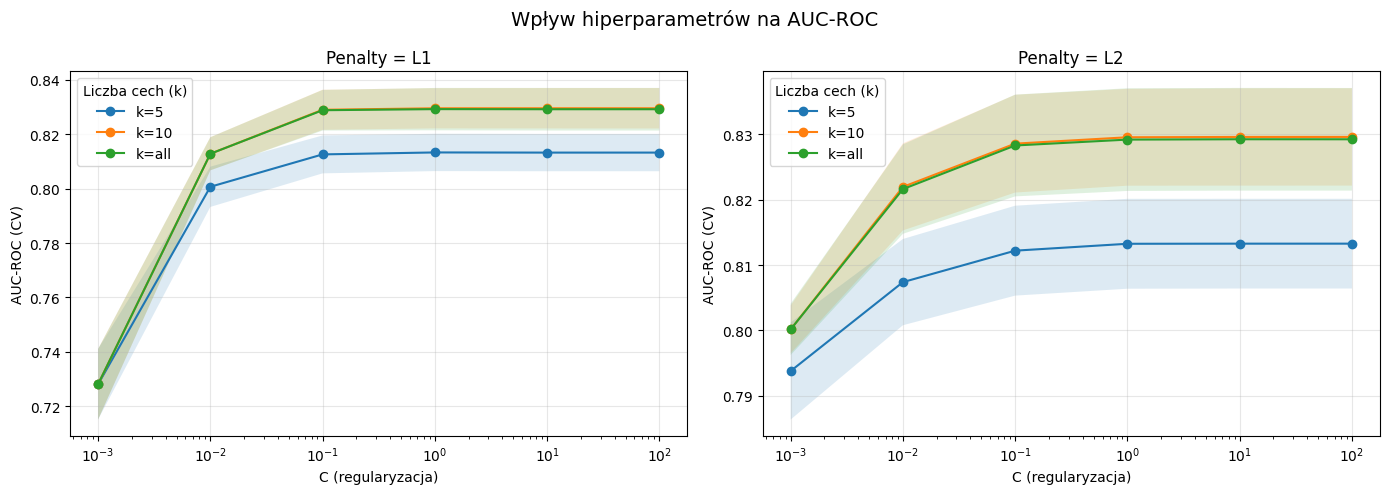

In [ ]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

param_grid = {
    'selector__k':  [5, 8, 10, 12, 'all'],
    'clf__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear']   # jedyny solver obsługujący L1 i L2
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',      # optymalizujemy AUC, nie accuracy
    n_jobs=-1,              # wszystkie rdzenie procesora
    verbose=1,
    return_train_score=True
)

print("Uruchamiam GridSearch (może chwilę potrwać)...")
grid.fit(X_train, y_train)

print(f"\n=== Najlepsze parametry ===")
print(grid.best_params_)
print(f"Najlepszy AUC (CV): {grid.best_score_:.4f}")

# --- Top 10 kombinacji ---
results = pd.DataFrame(grid.cv_results_)
top10 = (results[['param_clf__C', 'param_clf__penalty',
                   'param_selector__k', 'mean_test_score', 'std_test_score']]
         .sort_values('mean_test_score', ascending=False)
         .head(10))
print("\n=== Top 10 kombinacji ===")
print(top10.to_string(index=False))

# --- Wykres: wpływ C na AUC dla L1 i L2 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, penalty in zip(axes, ['l1', 'l2']):
    subset = results[results['param_clf__penalty'] == penalty]
    for k in [5, 10, 'all']:
        mask = subset['param_selector__k'] == k
        if mask.sum() == 0:
            continue
        sub = subset[mask].sort_values('param_clf__C')
        ax.plot(sub['param_clf__C'], sub['mean_test_score'],
                marker='o', label=f'k={k}')
        ax.fill_between(sub['param_clf__C'],
                        sub['mean_test_score'] - sub['std_test_score'],
                        sub['mean_test_score'] + sub['std_test_score'],
                        alpha=0.15)
    ax.set_xscale('log')
    ax.set_xlabel('C (regularyzacja)')
    ax.set_ylabel('AUC-ROC (CV)')
    ax.set_title(f'Penalty = {penalty.upper()}')
    ax.legend(title='Liczba cech (k)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Wpływ hiperparametrów na AUC-ROC', fontsize=14)
plt.tight_layout()
plt.savefig('hyperparams.png', dpi=150)
plt.show()

AUC-ROC finalny model: 0.8491
Zysk finalnego modelu (próg 0.68): -61,502

=== Współczynniki (posortowane wg ważności) ===
            Cecha  Współczynnik
  NumOfProducts_4      4.347185
  NumOfProducts_3      2.494442
  NumOfProducts_2     -1.469436
Geography_Germany      0.940557
              Age      0.773898
      Gender_Male     -0.545388
   IsActiveMember     -0.443222
  Geography_Spain      0.103857
      CreditScore     -0.075658
          Balance      0.010040


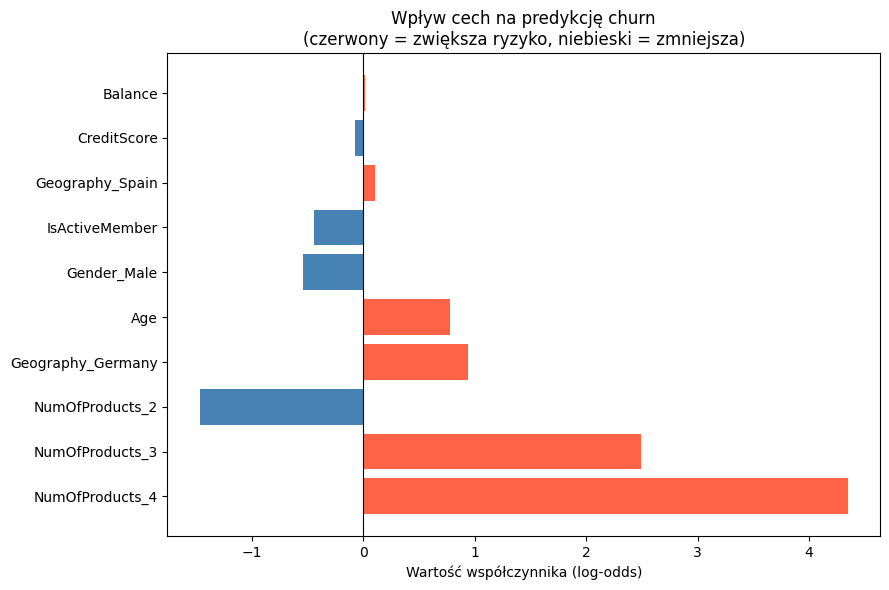

In [ ]:
# --- Zbuduj finalny model z najlepszymi parametrami ---
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(f_classif, k=10)),
    ('clf', LogisticRegression(
        C=1,                        # najprostszy z równie dobrych
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

best_pipeline.fit(X_train, y_train)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print(f"AUC-ROC finalny model: {roc_auc_score(y_test, y_proba_best):.4f}")

# --- Zysk przy optymalnym progu 0.68 ---
y_test_r = y_test.reset_index(drop=True)
sal_test  = X_test['EstimatedSalary'].reset_index(drop=True)
profit_final = business_profit(y_test_r, y_proba_best, 0.68, sal_test)
print(f"Zysk finalnego modelu (próg 0.68): {profit_final:,.0f}")

# --- Wyciągnij nazwy cech po selekcji ---
feature_names_num = numerical_cols
feature_names_cat = (best_pipeline.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical_cols).tolist())
all_features = feature_names_num + feature_names_cat

selector = best_pipeline.named_steps['selector']
selected_mask = selector.get_support()
selected_features = [f for f, s in zip(all_features, selected_mask) if s]

# --- Współczynniki modelu ---
coefs = best_pipeline.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({
    'Cecha': selected_features,
    'Współczynnik': coefs
}).sort_values('Współczynnik', key=abs, ascending=False)

print("\n=== Współczynniki (posortowane wg ważności) ===")
print(coef_df.to_string(index=False))

# --- Wykres współczynników ---
plt.figure(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Współczynnik']]
plt.barh(coef_df['Cecha'], coef_df['Współczynnik'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Wartość współczynnika (log-odds)')
plt.title('Wpływ cech na predykcję churn\n(czerwony = zwiększa ryzyko, niebieski = zmniejsza)')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=150)
plt.show()

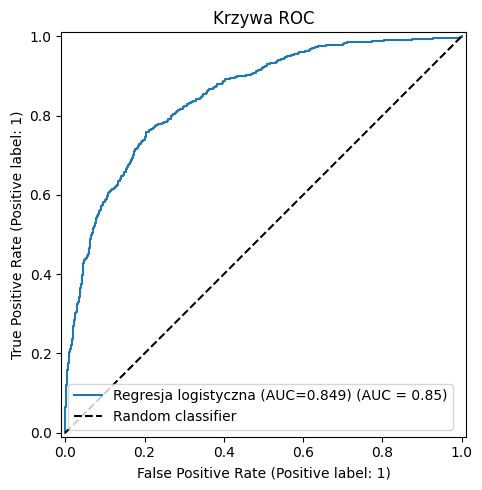

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=ax,
                                  name=f'Regresja logistyczna (AUC=0.849)')
ax.plot([0,1],[0,1],'k--', label='Random classifier')
ax.set_title('Krzywa ROC')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()